# Exercício 1 — Análise de rede com GEPHI

Este notebook guia a análise da rede de exemplo da disciplina **IA006** usando:
1. **Python + networkx** — análise computacional direta no Jupyter
2. **GEPHI** — visualização e exploração interativa (software externo)

Os dados descrevem as relações entre alunos, professora, monitor e laboratório num ambiente de aprendizado.

> **Materiais necessários:** `gephi_exemplo_nos.csv` e `gephi_exemplo_arestas.csv` na mesma pasta deste notebook.

## 1. Carregar os dados

In [9]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import os

_candidates = [
    os.path.join(os.getcwd(), 'gephi_exemplo_nos.csv'),
    os.path.join(os.getcwd(), 'tarefas', 'aula05', 'gephi_exemplo_nos.csv'),
]
for _p in _candidates:
    if os.path.exists(_p):
        PASTA = os.path.dirname(_p)
        break

df_nos = pd.read_csv(os.path.join(PASTA, 'gephi_exemplo_nos.csv'))
df_arestas = pd.read_csv(os.path.join(PASTA, 'gephi_exemplo_arestas.csv'))

print('Nós:')
display(df_nos)
print('\nArestas:')
display(df_arestas)

Nós:


,Id,Label,Tipo,Grupo
0,A1,Ana,Aluno,Grupo 1
1,A2,Bruno,Aluno,Grupo 1
2,A3,Carla,Aluno,Grupo 1
3,A4,Diego,Aluno,Grupo 1
4,A5,Eva,Aluno,Grupo 2
5,A6,Felipe,Aluno,Grupo 2
6,A7,Gabi,Aluno,Grupo 2
7,A8,Hugo,Aluno,Grupo 2
8,P1,Prof. Marta,Professor,Docente
9,M1,Monitor Leo,Monitor,Apoio



Arestas:


,Source,Target,Type,Weight,Label
0,P1,A1,Directed,3,orienta
1,P1,A2,Directed,3,orienta
2,P1,A5,Directed,3,orienta
3,P1,A6,Directed,3,orienta
4,M1,A3,Directed,2,apoia
5,M1,A4,Directed,2,apoia
6,M1,A7,Directed,2,apoia
7,M1,A8,Directed,2,apoia
8,A1,A2,Undirected,1,colabora
9,A2,A3,Undirected,1,colabora


## 2. Construir o grafo

A rede é **mista**: arestas orientadas (orientação, apoio, uso do lab) e não-orientadas (colaboração, troca entre grupos).
No Python vamos usar um `DiGraph` (grafo direcionado) e representar arestas não-orientadas como **arestas nos dois sentidos**.

In [10]:
G = nx.DiGraph()

for _, row in df_nos.iterrows():
    G.add_node(row['Id'], label=row['Label'], tipo=row['Tipo'], grupo=row['Grupo'])

for _, row in df_arestas.iterrows():
    G.add_edge(row['Source'], row['Target'],
               weight=row['Weight'], tipo=row['Label'])
    if row['Type'] == 'Undirected':
        G.add_edge(row['Target'], row['Source'],
                   weight=row['Weight'], tipo=row['Label'])

print(f'Nós: {G.number_of_nodes()}')
print(f'Arestas (total, incluindo bidirecionais): {G.number_of_edges()}')
print(f'\nArestas direcionadas originais: {len(df_arestas[df_arestas["Type"] == "Directed"])}')
print(f'Arestas não-orientadas originais: {len(df_arestas[df_arestas["Type"] == "Undirected"])}')

Nós: 11
Arestas (total, incluindo bidirecionais): 28

Arestas direcionadas originais: 12
Arestas não-orientadas originais: 8


## 3. Visualizar a rede

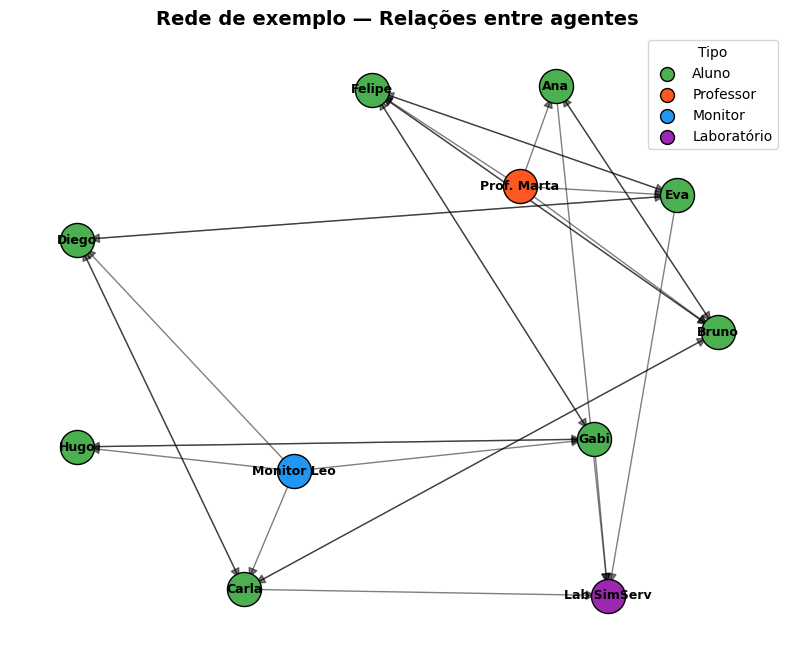

Figura salva como aula_05_exercicio_01_rede.png


In [11]:
cores_tipo = {
    'Aluno': '#4CAF50',
    'Professor': '#FF5722',
    'Monitor': '#2196F3',
    'Laboratório': '#9C27B0',
}

pos = nx.spring_layout(G, seed=42, k=2)

fig, ax = plt.subplots(figsize=(10, 8))

for node, data in G.nodes(data=True):
    cor = cores_tipo.get(data['tipo'], '#888888')
    nx.draw_networkx_nodes(G, pos, nodelist=[node],
                           node_color=cor, node_size=600,
                           edgecolors='black', linewidths=1, ax=ax)

nx.draw_networkx_edges(G, pos, alpha=0.5, arrows=True, arrowsize=15, ax=ax)

labels = {n: G.nodes[n]['label'] for n in G.nodes}
nx.draw_networkx_labels(G, pos, labels, font_size=9, font_weight='bold', ax=ax)

for tipo, cor in cores_tipo.items():
    ax.scatter([], [], c=cor, label=tipo, s=100, edgecolors='black', linewidths=1)
ax.legend(title='Tipo', fontsize=10)

ax.set_title('Rede de exemplo — Relações entre agentes', fontsize=14, fontweight='bold')
ax.axis('off')

import os
_repo = os.getcwd()
for _ in range(5):
    if os.path.exists(os.path.join(_repo, 'setup.sh')):
        break
    _repo = os.path.dirname(_repo)
PASTA_MOODLE = os.path.join(_repo, 'work', 'tarefas_moodle')
PASTA_AULA = os.path.join(PASTA_MOODLE, 'tarefa_aula05')
os.makedirs(PASTA_AULA, exist_ok=True)

plt.savefig(os.path.join(PASTA_AULA, 'aula_05_exercicio_01_rede.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('Figura salva como aula_05_exercicio_01_rede.png')

## 4. Métricas da rede

In [12]:
df_graus = pd.DataFrame({
    'No': list(G.nodes()),
    'Label': [G.nodes[n]['label'] for n in G.nodes],
    'Tipo': [G.nodes[n]['tipo'] for n in G.nodes],
    'Grau_Entrada': [G.in_degree(n) for n in G.nodes],
    'Grau_Saida': [G.out_degree(n) for n in G.nodes],
    'Grau_Total': [G.degree(n) for n in G.nodes],
}).sort_values('Grau_Total', ascending=False).reset_index(drop=True)
display(df_graus)

,No,Label,Tipo,Grau_Entrada,Grau_Saida,Grau_Total
0,A2,Bruno,Aluno,4,3,7
1,A6,Felipe,Aluno,4,3,7
2,A3,Carla,Aluno,3,3,6
3,A7,Gabi,Aluno,3,3,6
4,A5,Eva,Aluno,3,3,6
5,A4,Diego,Aluno,3,2,5
6,A1,Ana,Aluno,2,2,4
7,P1,Prof. Marta,Professor,0,4,4
8,M1,Monitor Leo,Monitor,0,4,4
9,L1,Lab SimServ,Laboratório,4,0,4


In [13]:
GU = G.to_undirected()

centralidade_grau = nx.degree_centrality(GU)
betweenness = nx.betweenness_centrality(GU)
closeness = nx.closeness_centrality(GU)
clustering = nx.clustering(GU)

df_metricas = pd.DataFrame({
    'No': list(G.nodes()),
    'Label': [G.nodes[n]['label'] for n in G.nodes],
    'Centralidade_Grau': [centralidade_grau[n] for n in G.nodes],
    'Betweenness': [betweenness[n] for n in G.nodes],
    'Closeness': [closeness[n] for n in G.nodes],
    'Cluster': [clustering[n] for n in G.nodes],
}).sort_values('Centralidade_Grau', ascending=False).reset_index(drop=True)
display(df_metricas)

,No,Label,Centralidade_Grau,Betweenness,Closeness,Cluster
0,A2,Bruno,0.4,0.087037,0.588235,0.333333
1,A3,Carla,0.4,0.122222,0.625000,0.166667
2,A5,Eva,0.4,0.096296,0.588235,0.166667
3,L1,Lab SimServ,0.4,0.133333,0.625000,0.000000
4,A6,Felipe,0.4,0.114815,0.625000,0.333333
5,A7,Gabi,0.4,0.174074,0.625000,0.166667
6,P1,Prof. Marta,0.4,0.038889,0.555556,0.500000
7,M1,Monitor Leo,0.4,0.096296,0.555556,0.333333
8,A1,Ana,0.3,0.022222,0.500000,0.333333
9,A4,Diego,0.3,0.048148,0.555556,0.333333


## 5. Pergunta 1

> **A rede mostra a relação entre agentes de mesma natureza?**

Observe o grafo, os tipos dos nós e os tipos das arestas. Agentes do mesmo tipo (ex.: aluno-aluno) estão conectados? E agentes de tipos diferentes? 

**Responda na célula abaixo:**

In [14]:
resposta_pergunta_1 = '''
(A IA preenchera esta resposta na secao "Gerar resposta com IA".)
'''
print(resposta_pergunta_1)


(A IA preenchera esta resposta na secao "Gerar resposta com IA".)



## 6. Gerar resposta com IA

Execute a célula abaixo para que a IA analise os dados gerados e preencha automaticamente a resposta.
Você pode editar o resultado depois se quiser.

In [15]:
from dotenv import load_dotenv
load_dotenv()
import os, json
from urllib.request import Request, urlopen

MODELO = os.getenv('OLLAMA_MODEL', 'ministral-3:3b')
BASE_URL = os.getenv('OLLAMA_BASE_URL', 'https://api.ollama.com').rstrip('/')
API_KEY = os.getenv('OLLAMA_API_KEY')

prompt = f'''Voce e um assistente de um curso de sistemas de muitos agentes.
Responda em portugues, de forma clara e objetiva (maximo 3 paragrafos).

Pergunta: A rede mostra a relacao entre agentes de mesma natureza?

Dados da rede:

Nos:
{df_nos.to_markdown(index=False)}

Arestas:
{df_arestas.to_markdown(index=False)}

Grau dos nos:
{df_graus.to_markdown(index=False)}

Centralidade:
{df_metricas.to_markdown(index=False)}'''

headers = {
    'Content-Type': 'application/json',
    'User-Agent': 'Mozilla/5.0',
    'Accept': 'application/json',
}
if API_KEY:
    headers['Authorization'] = f'Bearer {API_KEY}'

payload = {
    'model': MODELO,
    'messages': [{'role': 'user', 'content': prompt}],
    'stream': False,
    'options': {'temperature': 0.3, 'top_p': 0.9, 'num_predict': 800},
}

try:
    req = Request(
        BASE_URL + '/api/chat',
        data=json.dumps(payload).encode('utf-8'),
        headers=headers,
        method='POST',
    )
    with urlopen(req, timeout=60) as resp:
        dados = json.loads(resp.read().decode('utf-8'))
    resposta = dados.get('message', {}).get('content', '').strip()
    if resposta:
        resposta_pergunta_1 = resposta
        print('Resposta gerada com sucesso!')
    else:
        print('IA retornou resposta vazia.')
except Exception as e:
    print(f'Erro ao consultar IA: {type(e).__name__}: {e}')

print()
print('Resposta atual:')
print(resposta_pergunta_1)

Resposta gerada com sucesso!

Resposta atual:
Sim, a rede **simboliza parcialmente a relação entre agentes de mesma natureza**, mas de forma limitada. Os vínculos **undirected** (colaborações) entre alunos (ex.: A1-A2, A2-A3) reforçam interações internas dentro de grupos, enquanto as conexões **directed** (orienta/apoia) entre professores e alunos (P1-A1, M1-A3) destacam papéis hierárquicos ou de suporte. No entanto, **agentes de mesmo tipo (alunos) não são conectados diretamente por arestas direcionadas**, apenas por colaborações não direcionadas ou trocas entre grupos.

A **centralidade de grau** mostra que alguns alunos (como Bruno e Felipe) têm maior interação dentro do grupo, enquanto a **colaboração entre grupos** (ex.: A4-A5) cria pontes entre sub-redes de mesma natureza. Apesar disso, a rede não estabelece uma rede **homogênea** de agentes do mesmo tipo, mas sim uma estrutura **heterogênea**, onde interações ocorrem principalmente entre grupos ou papéis distintos.

Para analisa

## 7. Passo a passo no GEPHI

1. **Baixe e instale** o GEPHI em [gephi.org](https://gephi.org/desktop/)
2. **Abra o GEPHI** e crie um novo projeto
3. **Importe os nós:** *Laboratório de dados* → *Arquivo* → *Importar planilha* → selecione `gephi_exemplo_nos.csv` → *Tabela de Nós*
4. **Importe as arestas:** mesmo caminho com `gephi_exemplo_arestas.csv` → *Tabela de Arestas*
5. **Visualize:** painel *Visão Geral* → *Distribuição* → **ForceAtlas 2**
6. **Aparência:** colorir por `Grupo`, dimensionar por `Grau`, ativar rótulos
7. **Estatísticas:** explore grau médio, diâmetro, modularidade etc.
8. **Exporte:** *Visualização Prévia* → ajuste para publicação

## 8. Gerar Markdown para Moodle

Execute a célula abaixo depois de gerar a resposta com IA (ou editá-la manualmente).
Ela salva tudo em `work/tarefas_moodle/` na raiz do repositório.

In [16]:
import os
import shutil
import subprocess
from datetime import datetime

_repo = os.getcwd()
for _ in range(5):
    if os.path.exists(os.path.join(_repo, 'setup.sh')):
        break
    _repo = os.path.dirname(_repo)
PASTA_MOODLE = os.path.join(_repo, 'work', 'tarefas_moodle')
os.makedirs(PASTA_MOODLE, exist_ok=True)
PASTA_AULA = os.path.join(PASTA_MOODLE, 'tarefa_aula05')
os.makedirs(PASTA_AULA, exist_ok=True)

agora = datetime.now().strftime('%Y-%m-%d %H:%M')

PATH_MD = os.path.join(PASTA_AULA, 'aula_05_exercicio_01.md')
with open(PATH_MD, 'w', encoding='utf-8') as f:
    f.write('# Aula 05 — Exercício 01: Análise de rede com GEPHI\n\n')
    f.write(f'_Executado em: {agora}_\n\n')
    f.write('---\n\n')
    f.write('## Dados carregados\n\n')
    f.write('### Nós\n\n')
    f.write(df_nos.to_markdown(index=False))
    f.write('\n\n')
    f.write('### Arestas\n\n')
    f.write(df_arestas.to_markdown(index=False))
    f.write('\n\n')
    f.write('---\n\n')
    f.write('## Visualização da rede\n\n')
    f.write('![Rede de exemplo](aula_05_exercicio_01_rede.png)\n\n')
    f.write('---\n\n')
    f.write('## Métricas\n\n')
    f.write('### Grau dos nós\n\n')
    f.write(df_graus.to_markdown(index=False))
    f.write('\n\n')
    f.write('### Centralidade e agrupamento\n\n')
    f.write(df_metricas.to_markdown(index=False))
    f.write('\n\n')
    f.write('---\n\n')
    f.write('## Resposta do aluno — Pergunta 1\n\n')
    f.write(resposta_pergunta_1.strip())
    f.write('\n')

PATH_PDF = PATH_MD.replace('.md', '.pdf')
if shutil.which('pandoc'):
    subprocess.run(['pandoc', PATH_MD, '-o', PATH_PDF, '--pdf-engine=xelatex', '--resource-path', PASTA_AULA, '-V', 'mainfont=DejaVu Serif'], check=True)
else:
    print('Aviso: pandoc nao instalado. Execute ./setup.sh para instalar.')
print(f'Markdown: {os.path.abspath(PATH_MD)}')
print(f'PDF:      {os.path.abspath(PATH_PDF)}')

Markdown: /l/disk0/viniciusd/Projetos/simserv_jupyter_env/work/tarefas_moodle/aula_05_exercicio_01.md
PDF:      /l/disk0/viniciusd/Projetos/simserv_jupyter_env/work/tarefas_moodle/aula_05_exercicio_01.pdf
